# Phase 1 — Workspace Scaffold & ELPD Blender Validation

Run each cell in order.  Cell 1 builds the directory tree, Cell 2 installs deps,
Cells 3-5 validate the config loader, the ELPD blender, and produce the ELPD surface plot.

In [ ]:
# ── Cell 1: Directory Scaffold ────────────────────────────────────────────
import os

DIRS = [
    'configs',
    'src/attacks',
    'src/models',
    'src/utils',
    'src/data',
    'notebooks',
    'results/logs',
    'results/checkpoints',
    'results/plots',
    'scripts',
]

for d in DIRS:
    os.makedirs(d, exist_ok=True)
    if d.startswith('src'):
        init = os.path.join(d, '__init__.py')
        if not os.path.exists(init):
            open(init, 'w').close()

print('Directory tree created:')
for root, dirs, files in os.walk('.'):
    dirs[:] = [d for d in sorted(dirs) if not d.startswith('.') and d != '__pycache__']
    depth = root.replace('.', '').count(os.sep)
    indent = '    ' * depth
    print(f'{indent}{os.path.basename(root)}/')
    for f in sorted(files):
        print(f'{indent}    {f}')

In [ ]:
# ── Cell 2: Install Dependencies ─────────────────────────────────────────
# Run once on a fresh AutoDL pod.  Comment out after first run.
!pip install -q torch torchvision pyyaml wandb

In [1]:
# ── Cell 3: Validate Config Loader ───────────────────────────────────────
import os
import sys, logging
logging.basicConfig(level=logging.INFO)

PROJECT_ROOT = os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.utils.config_loader import load_config, dump_config

cfg = load_config('configs/config.yaml')

print(f'Experiment  : {cfg.experiment.name}')
print(f'Target arch : {cfg.models.target.arch}')
print(f'Surrogate   : {cfg.models.surrogate.arch}')
print(f'ε           : {cfg.attack.epsilon}')
print(f'Query budget: {cfg.attack.query_budget}')
print(f'ELPD method : {cfg.elpd_blender.method}')
print(f'η grid pts  : {cfg.elpd_blender.eta_grid.n_points}')
print()
print('Config validation passed ✓')

INFO:src.utils.config_loader:Loaded config from /Users/eyoel/Documents/projects/adversarial_ml/configs/config.yaml


Experiment  : elpd_blend_attack_v1
Target arch : resnet50
Surrogate   : vgg16_bn
ε           : 0.05
Query budget: 5000
ELPD method : waic
η grid pts  : 21

Config validation passed ✓


In [2]:
# ── Cell 4: ELPD Blender Smoke Test ──────────────────────────────────────
#
# The ELPD score is: lppd(η) − T·p_waic(η)
#   lppd(η)  = −mean_i[||g_i − μ(η)||²]      (negative MSE: higher = better fit)
#   p_waic(η) = std_i[||g_i − μ(η)||²]        (inconsistency penalty)
#
# Expected behaviour:
#   A — aligned surrogate  → ELPD peaks at high η (trust the surrogate)
#   B — opposing surrogate → ELPD peaks at low η  (ignore the surrogate)
#   C — LOO-PSIS path agrees with WAIC direction
#   D — cosine-var fallback fires when q < min_samples_for_waic

import torch
from src.attacks.elpd_blender import ELPDBlender

cfg = load_config('configs/config.yaml')
D   = 512
q   = cfg.query_estimator.n_samples

torch.manual_seed(cfg.experiment.seed)

g_true = torch.randn(D)
g_true /= g_true.abs().max()

# Scenario A — surrogate ≈ target (small noise) ───────────────────────────
g_sur_good  = g_true + 0.01 * torch.randn(D)
g_tgt_draws = g_true.unsqueeze(0) + 0.05 * torch.randn(q, D)

blender  = ELPDBlender(cfg.elpd_blender, sigma=cfg.query_estimator.sigma)
result_A = blender.step(g_sur_good, g_tgt_draws)
print(f'[A – aligned]      η_raw={result_A.eta_raw:.3f}  '
      f'η_smooth={result_A.eta_smoothed:.3f}  '
      f'cos={result_A.diagnostics["cosine_sim_sur_tgt"]:+.3f}  '
      f'method={result_A.method_used}')
print(f'  ELPD surface: η=0→{result_A.elpd_values[0]:.4f}, '
      f'η=0.5→{result_A.elpd_values[10]:.4f}, '
      f'η=1→{result_A.elpd_values[-1]:.4f}')
assert result_A.eta_raw > 0.4, (
    f'Expected η > 0.4 for aligned surrogate, got {result_A.eta_raw:.3f}'
)

# Scenario B — surrogate opposes target ───────────────────────────────────
g_sur_bad = -g_true + 0.01 * torch.randn(D)

blender.reset()
result_B = blender.step(g_sur_bad, g_tgt_draws)
print(f'[B – opposing]     η_raw={result_B.eta_raw:.3f}  '
      f'η_smooth={result_B.eta_smoothed:.3f}  '
      f'cos={result_B.diagnostics["cosine_sim_sur_tgt"]:+.3f}  '
      f'method={result_B.method_used}')
print(f'  ELPD surface: η=0→{result_B.elpd_values[0]:.4f}, '
      f'η=0.5→{result_B.elpd_values[10]:.4f}, '
      f'η=1→{result_B.elpd_values[-1]:.4f}')
assert result_B.eta_raw < 0.3, (
    f'Expected η < 0.3 for opposing surrogate, got {result_B.eta_raw:.3f}'
)

# Scenario C — LOO-PSIS ───────────────────────────────────────────────────
cfg.elpd_blender.method = 'loo_psis'
blender_psis = ELPDBlender(cfg.elpd_blender, sigma=cfg.query_estimator.sigma)
result_C     = blender_psis.step(g_sur_good, g_tgt_draws)
print(f'[C – LOO-PSIS]     η_raw={result_C.eta_raw:.3f}  '
      f'k̂={result_C.pareto_k:.3f}  method={result_C.method_used}')

# Scenario D — cosine-var fallback (2 draws < min_samples_for_waic=4) ─────
cfg.elpd_blender.method = 'waic'
blender_cv = ELPDBlender(cfg.elpd_blender, sigma=cfg.query_estimator.sigma)
result_D   = blender_cv.step(g_sur_good, g_tgt_draws[:2])
print(f'[D – cosine-var]   η_raw={result_D.eta_raw:.3f}  method={result_D.method_used}')

print()
print('All ELPD Blender smoke tests passed ✓')

INFO:src.utils.config_loader:Loaded config from /Users/eyoel/Documents/projects/adversarial_ml/configs/config.yaml


[A – aligned]      η_raw=0.500  η_smooth=0.500  cos=+0.999  method=waic
  ELPD surface: η=0→0.9883, η=0.5→0.9885, η=1→0.9883
[B – opposing]     η_raw=0.000  η_smooth=0.000  cos=-0.999  method=waic
  ELPD surface: η=0→0.9883, η=0.5→-0.2427, η=1→-0.9897
[C – LOO-PSIS]     η_raw=0.550  k̂=0.146  method=loo_psis
[D – cosine-var]   η_raw=0.000  method=cosine_var

All ELPD Blender smoke tests passed ✓


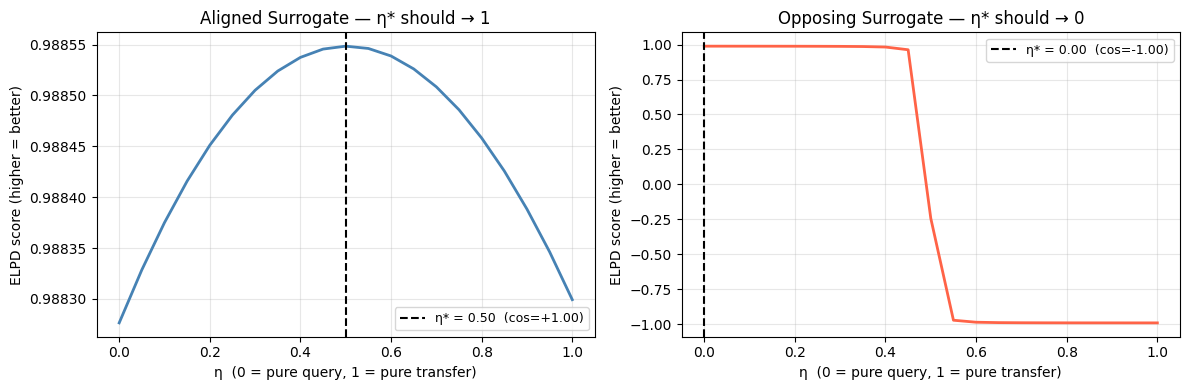

Plot saved → results/plots/elpd_surface_smoke_test.png


In [3]:
# ── Cell 5: ELPD Surface Plot ─────────────────────────────────────────────
import matplotlib.pyplot as plt

cfg.elpd_blender.method = 'waic'
blender_plot = ELPDBlender(cfg.elpd_blender, sigma=cfg.query_estimator.sigma)
res_al  = blender_plot.step(g_sur_good, g_tgt_draws)
blender_plot.reset()
res_bad = blender_plot.step(g_sur_bad, g_tgt_draws)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, res, title, colour in zip(
    axes,
    [res_al, res_bad],
    ['Aligned Surrogate — η* should → 1', 'Opposing Surrogate — η* should → 0'],
    ['steelblue', 'tomato'],
):
    eta_np  = res.eta_grid.numpy()
    elpd_np = res.elpd_values.numpy()
    ax.plot(eta_np, elpd_np, color=colour, linewidth=2)
    ax.axvline(
        res.eta_raw, color='black', linestyle='--',
        label=f'η* = {res.eta_raw:.2f}  (cos={res.diagnostics["cosine_sim_sur_tgt"]:+.2f})'
    )
    ax.set_xlabel('η  (0 = pure query, 1 = pure transfer)')
    ax.set_ylabel('ELPD score (higher = better)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
os.makedirs('results/plots', exist_ok=True)
plt.savefig('results/plots/elpd_surface_smoke_test.png', dpi=150)
plt.show()
print('Plot saved → results/plots/elpd_surface_smoke_test.png')